# Sklearn Pipelines and Structured ML Workflows

How can Sklearn Pipelines simplify and streamline your ML workflow?

Instead of writing separate code blocks for cleaning, scaling, encoding and modelling, sklearn pipelines unify everything into a **single, consistent object**.

## Why Manual Preprocessing Fails

| Risk | Consequence |
|---|---|
| Inconsistent Transformations | Scaling training data differently from test data |
| Leakage Risk | Computing statistics using the full dataset |
| Deployment Mismatch | Production environment replicates notebook logic incorrectly |

## Three Benefits of Pipelines
1. **Prevent Leakage** — transformers fit only on training data
2. **Improve Reproducibility** — exact same steps applied consistently
3. **Cleaner Experimentation** — swap components without rewriting code

In [1]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error
import joblib

np.random.seed(42)

# Mixed-type dataset: numerical + categorical columns
n = 2000
df = pd.DataFrame({
    'age':      np.random.randint(18, 70, n).astype(float),
    'income':   np.random.exponential(50000, n).round(2),
    'score':    np.random.uniform(1, 10, n).round(2),
    'city':     np.random.choice(['Mumbai', 'Delhi', 'Bangalore', 'Chennai'], n),
    'tier':     np.random.choice(['Bronze', 'Silver', 'Gold'], n),
})

# Introduce missings
df.loc[np.random.choice(df.index, 100), 'age']    = np.nan
df.loc[np.random.choice(df.index, 80),  'income'] = np.nan
df.loc[np.random.choice(df.index, 50),  'city']   = np.nan

# Target: revenue proxy
df['revenue'] = 200 * df['score'] + 0.01 * df['income'].fillna(50000) + np.random.randn(n) * 500

X = df.drop('revenue', axis=1)
y = df['revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (1600, 5), Test: (400, 5)


## 1. Basic Pipeline

A pipeline chains steps sequentially. When you call `.fit()`, every preprocessing step is applied in order. When you call `.predict()`, the same transformations are automatically applied before inference.

In [2]:
# Simple numeric-only pipeline
num_cols_simple = ['age', 'income', 'score']

simple_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
    ('model',   Ridge()),
])

simple_pipeline.fit(X_train[num_cols_simple], y_train)
preds = simple_pipeline.predict(X_test[num_cols_simple])
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Simple pipeline RMSE: {rmse:.2f}")

Simple pipeline RMSE: 511.82


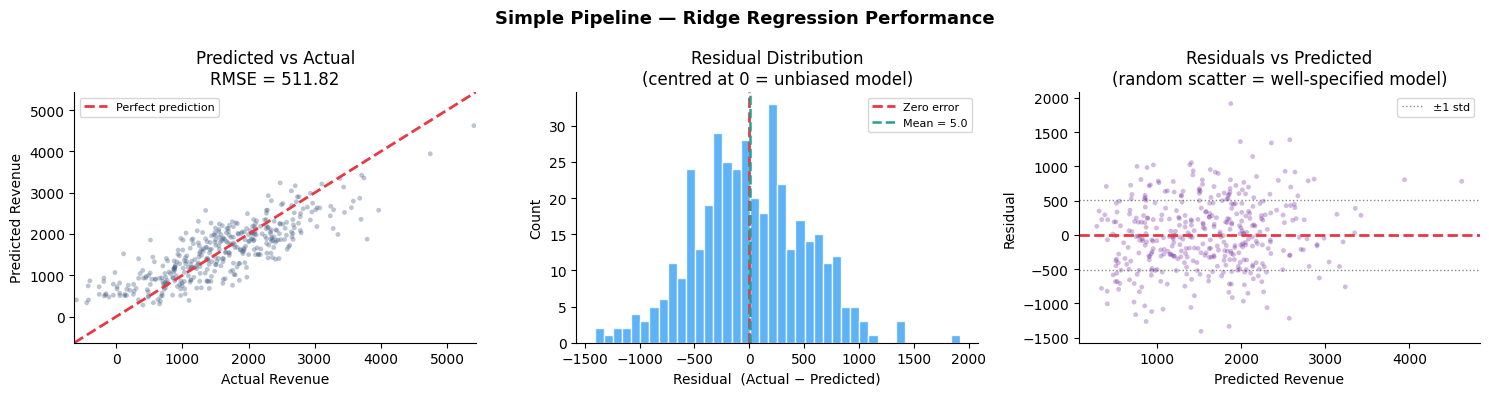

In [3]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test.values - preds
lims      = [min(y_test.min(), preds.min()) - 30,
             max(y_test.max(), preds.max()) + 30]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Simple Pipeline — Ridge Regression Performance',
             fontsize=13, fontweight='bold')

# Panel 1 — Predicted vs Actual scatter
axes[0].scatter(y_test, preds, alpha=0.35, s=12,
                color='#3d5a80', edgecolors='none')
axes[0].plot(lims, lims, color='#e63946', lw=2, ls='--', label='Perfect prediction')
axes[0].set_xlabel('Actual Revenue')
axes[0].set_ylabel('Predicted Revenue')
axes[0].set_title(f'Predicted vs Actual\nRMSE = {rmse:.2f}')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Residual distribution
axes[1].hist(residuals, bins=40, color='#42A5F5', edgecolor='white', alpha=0.85)
axes[1].axvline(0,                color='#e63946', lw=2,   ls='--', label='Zero error')
axes[1].axvline(residuals.mean(), color='#2a9d8f', lw=1.8, ls='--',
                label=f'Mean = {residuals.mean():.1f}')
axes[1].set_xlabel('Residual  (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(centred at 0 = unbiased model)')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

# Panel 3 — Residuals vs Predicted (pattern check)
axes[2].scatter(preds, residuals, alpha=0.3, s=12,
                color='#6A1B9A', edgecolors='none')
axes[2].axhline(0, color='#e63946', lw=2, ls='--')
axes[2].axhline( residuals.std(), color='#555', lw=1, ls=':', alpha=0.7, label='±1 std')
axes[2].axhline(-residuals.std(), color='#555', lw=1, ls=':', alpha=0.7)
axes[2].set_xlabel('Predicted Revenue')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Predicted\n(random scatter = well-specified model)')
axes[2].legend(fontsize=8)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 2. ColumnTransformer — Handling Mixed Data Types

Real datasets are rarely homogeneous. `ColumnTransformer` enables **parallel preprocessing**: different pipelines applied to different feature groups, then combined into a unified feature matrix.

In [4]:
numeric_features     = ['age', 'income', 'score']
categorical_features = ['city', 'tier']

# Sub-pipeline for numeric columns: impute → scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

# Sub-pipeline for categorical columns: impute → one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy='most_frequent')),
    ('encoder',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,     numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

# Full pipeline: preprocessing + model
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        Ridge()),
])

full_pipeline.fit(X_train, y_train)
preds = full_pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, preds))
print(f"Full pipeline RMSE (Ridge): {rmse:.2f}")

Full pipeline RMSE (Ridge): 512.82


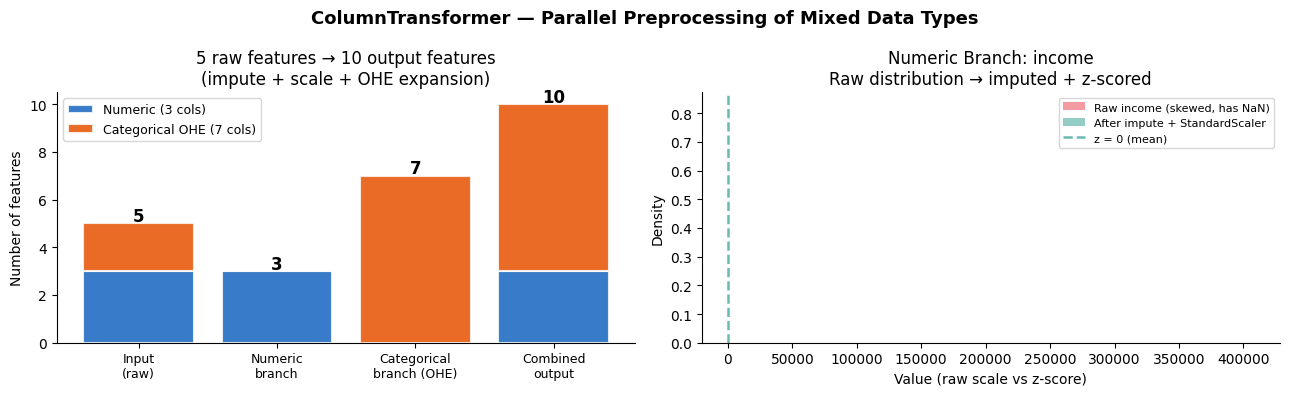

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Retrieve fitted preprocessor from the pipeline
fitted_pre   = full_pipeline.named_steps['preprocessor']
X_out        = fitted_pre.transform(X_train)
n_out        = X_out.shape[1]
n_num        = len(numeric_features)
n_cat        = n_out - n_num

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('ColumnTransformer — Parallel Preprocessing of Mixed Data Types',
             fontsize=13, fontweight='bold')

# Panel 1 — Feature count expansion stacked bar
stages  = ['Input\n(raw)', 'Numeric\nbranch', 'Categorical\nbranch (OHE)', 'Combined\noutput']
numeric_part = [n_num, n_num, 0, n_num]
cat_part     = [len(categorical_features), 0, n_cat, n_cat]

x = range(len(stages))
axes[0].bar(x, numeric_part, color='#1565C0', alpha=0.85,
            edgecolor='white', linewidth=1.5, label=f'Numeric ({n_num} cols)')
axes[0].bar(x, cat_part, bottom=numeric_part, color='#E65100', alpha=0.85,
            edgecolor='white', linewidth=1.5, label=f'Categorical OHE ({n_cat} cols)')
totals = [n_num + len(categorical_features), n_num, n_cat, n_out]
for xi, tot in zip(x, totals):
    axes[0].text(xi, tot + 0.1, str(tot), ha='center', fontweight='bold', fontsize=12)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(stages, fontsize=9)
axes[0].set_ylabel('Number of features')
axes[0].set_title(f'{len(numeric_features) + len(categorical_features)} raw features '
                  f'→ {n_out} output features\n(impute + scale + OHE expansion)')
axes[0].legend(fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Income distribution: raw vs after impute+scale (numeric branch output)
income_raw    = X_train['income'].dropna()
income_scaled = X_out[:, numeric_features.index('income')]

axes[1].hist(income_raw, bins=40, color='#e63946', alpha=0.5,
             density=True, label='Raw income (skewed, has NaN)')
axes[1].hist(income_scaled, bins=40, color='#2a9d8f', alpha=0.5,
             density=True, label='After impute + StandardScaler')
axes[1].axvline(0, color='#2a9d8f', lw=1.8, ls='--', alpha=0.7, label='z = 0 (mean)')
axes[1].set_xlabel('Value (raw scale vs z-score)')
axes[1].set_ylabel('Density')
axes[1].set_title('Numeric Branch: income\nRaw distribution → imputed + z-scored')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Swapping Models — Modular Experimentation

One of the most powerful advantages of pipelines is the ability to **swap models or preprocessing components easily** without rewriting code.

In [6]:
# Swap Ridge for RandomForestRegressor — only one line changes
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(n_estimators=100, random_state=42)),
])

rf_pipeline.fit(X_train, y_train)
preds_rf = rf_pipeline.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, preds_rf))
print(f"Full pipeline RMSE (RandomForest): {rmse_rf:.2f}")

Full pipeline RMSE (RandomForest): 536.31


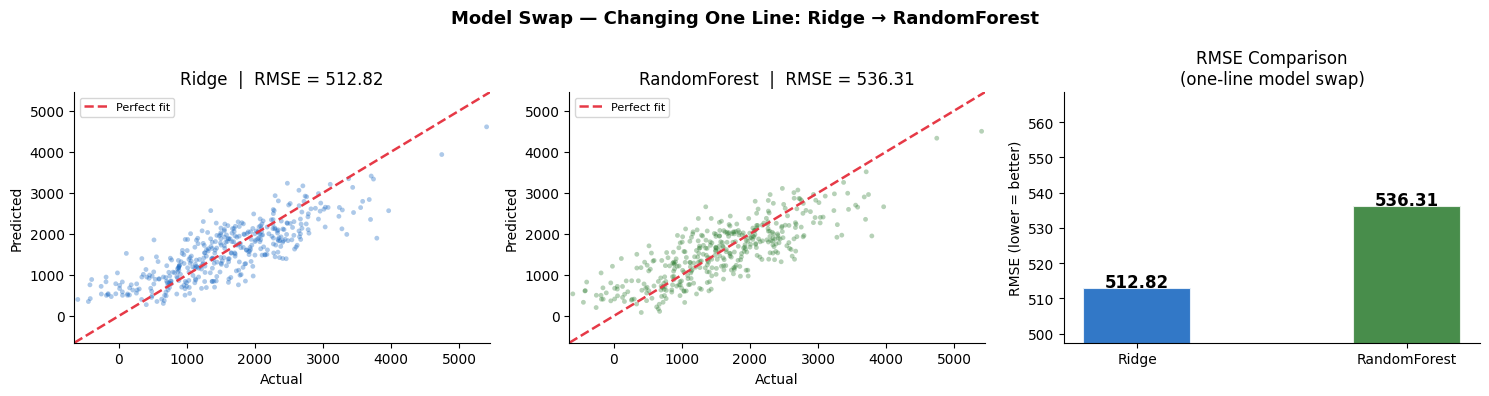

In [7]:
import matplotlib.pyplot as plt
import numpy as np

lims = [min(y_test.min(), preds.min(), preds_rf.min()) - 50,
        max(y_test.max(), preds.max(), preds_rf.max()) + 50]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model Swap — Changing One Line: Ridge → RandomForest',
             fontsize=13, fontweight='bold')

# Panel 1 — Ridge: predicted vs actual
axes[0].scatter(y_test, preds, alpha=0.35, s=12,
                color='#1565C0', edgecolors='none')
axes[0].plot(lims, lims, color='#e63946', lw=1.8, ls='--', label='Perfect fit')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Ridge  |  RMSE = {rmse:.2f}')
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — RandomForest: predicted vs actual
axes[1].scatter(y_test, preds_rf, alpha=0.35, s=12,
                color='#2E7D32', edgecolors='none')
axes[1].plot(lims, lims, color='#e63946', lw=1.8, ls='--', label='Perfect fit')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'RandomForest  |  RMSE = {rmse_rf:.2f}')
axes[1].set_xlim(lims); axes[1].set_ylim(lims)
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

# Panel 3 — RMSE bar comparison (y-axis zoomed to show difference)
models = ['Ridge', 'RandomForest']
rmses  = [rmse, rmse_rf]
colors = ['#1565C0', '#2E7D32']
bars   = axes[2].bar(models, rmses, color=colors,
                     edgecolor='white', linewidth=1.5, alpha=0.88, width=0.4)
for bar, val in zip(bars, rmses):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=12)
axes[2].set_ylabel('RMSE (lower = better)')
axes[2].set_title('RMSE Comparison\n(one-line model swap)')
axes[2].set_ylim(min(rmses) * 0.97, max(rmses) * 1.06)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Unified Hyperparameter Tuning with GridSearchCV

Tune **preprocessing parameters and model hyperparameters** together in a single `GridSearchCV` call — eliminates manual tracking and guarantees experiment consistency.

In [8]:
# Parameter grid covers both preprocessing and model choices
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'model__alpha': [0.1, 1.0, 10.0],
}

grid_search = GridSearchCV(
    full_pipeline,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV RMSE: {-grid_search.best_score_:.2f}")

best_model = grid_search.best_estimator_
test_rmse = np.sqrt(mean_squared_error(y_test, best_model.predict(X_test)))
print(f"Test RMSE:   {test_rmse:.2f}")

Best params: {'model__alpha': 10.0, 'preprocessor__num__imputer__strategy': 'mean'}
Best CV RMSE: 508.26
Test RMSE:   510.86


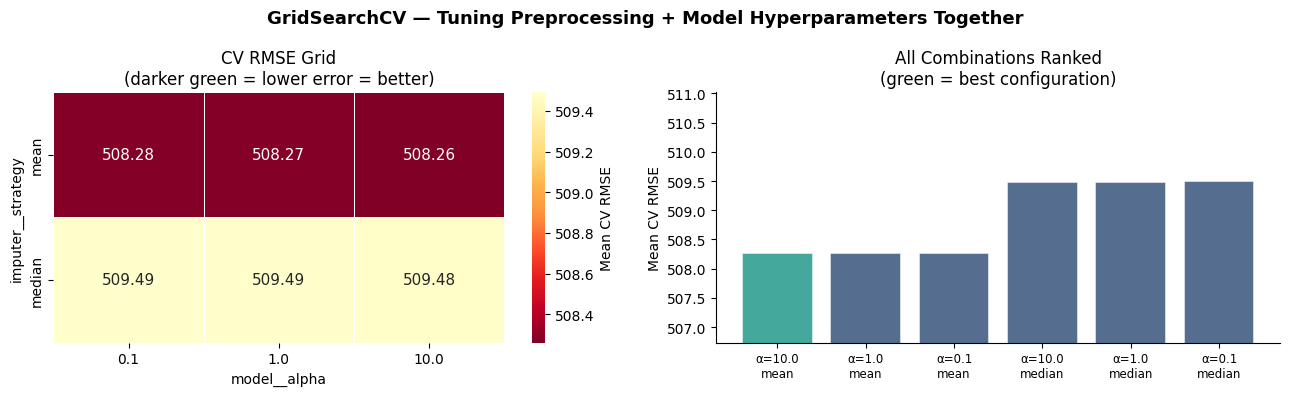


Best: {'model__alpha': 10.0, 'preprocessor__num__imputer__strategy': 'mean'}  →  CV RMSE = 508.26


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
results['mean_cv_rmse'] = -results['mean_test_score']
results['alpha']        = results['param_model__alpha'].astype(float)
results['imputer']      = results['param_preprocessor__num__imputer__strategy']

pivot = results.pivot(index='imputer', columns='alpha', values='mean_cv_rmse')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('GridSearchCV — Tuning Preprocessing + Model Hyperparameters Together',
             fontsize=13, fontweight='bold')

# Panel 1 — Heatmap: RMSE per (imputer_strategy × alpha) combination
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd_r',
            linewidths=0.6, ax=axes[0], annot_kws={'fontsize': 11},
            cbar_kws={'label': 'Mean CV RMSE'})
axes[0].set_title('CV RMSE Grid\n(darker green = lower error = better)')
axes[0].set_xlabel('model__alpha')
axes[0].set_ylabel('imputer__strategy')

# Panel 2 — All combinations ranked (best highlighted)
ranked = results.sort_values('mean_cv_rmse').reset_index(drop=True)
bar_labels = ranked.apply(
    lambda r: f"α={r['alpha']}\n{r['imputer']}", axis=1)
colors = ['#2a9d8f'] + ['#3d5a80'] * (len(ranked) - 1)
bars = axes[1].bar(range(len(ranked)), ranked['mean_cv_rmse'],
                   color=colors, edgecolor='white', linewidth=1.2, alpha=0.88)
axes[1].set_xticks(range(len(ranked)))
axes[1].set_xticklabels(bar_labels, fontsize=8.5)
axes[1].set_ylabel('Mean CV RMSE')
axes[1].set_title('All Combinations Ranked\n(green = best configuration)')
axes[1].set_ylim(ranked['mean_cv_rmse'].min() * 0.997,
                 ranked['mean_cv_rmse'].max() * 1.003)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nBest: {grid_search.best_params_}  →  CV RMSE = {-grid_search.best_score_:.2f}")

## 5. Cross-Validation Without Leakage

When pipelines are used correctly, **each fold independently fits preprocessing on its training portion** and applies transformations to the validation portion — no contamination between folds.

In [10]:
cv_scores = cross_val_score(
    full_pipeline,
    X_train, y_train,
    cv=5,
    scoring='neg_root_mean_squared_error'
)

cv_rmse = -cv_scores
print("Cross-validation RMSE per fold:")
for i, score in enumerate(cv_rmse, 1):
    print(f"  Fold {i}: {score:.2f}")
print(f"Mean: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")

Cross-validation RMSE per fold:
  Fold 1: 484.09
  Fold 2: 509.68
  Fold 3: 537.17
  Fold 4: 532.40
  Fold 5: 484.10
Mean: 509.49 ± 22.72


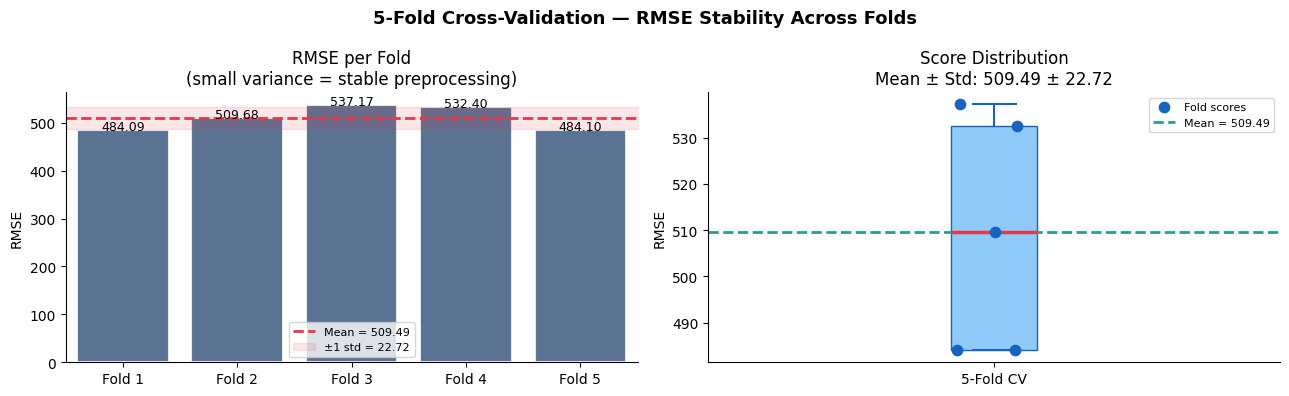

In [11]:
import matplotlib.pyplot as plt
import numpy as np

fold_labels = [f'Fold {i}' for i in range(1, 6)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('5-Fold Cross-Validation — RMSE Stability Across Folds',
             fontsize=13, fontweight='bold')

# Panel 1 — Bar per fold with mean line and ±1 std band
bars = axes[0].bar(fold_labels, cv_rmse,
                   color='#3d5a80', edgecolor='white', linewidth=1.5, alpha=0.85)
axes[0].axhline(cv_rmse.mean(), color='#e63946', lw=2, ls='--',
                label=f'Mean = {cv_rmse.mean():.2f}')
axes[0].fill_between(range(-1, 6),
                     cv_rmse.mean() - cv_rmse.std(),
                     cv_rmse.mean() + cv_rmse.std(),
                     alpha=0.12, color='#e63946',
                     label=f'±1 std = {cv_rmse.std():.2f}')
for bar, val in zip(bars, cv_rmse):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.3,
                 f'{val:.2f}', ha='center', fontsize=9)
axes[0].set_ylabel('RMSE')
axes[0].set_title('RMSE per Fold\n(small variance = stable preprocessing)')
axes[0].set_xlim(-0.5, 4.5)
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Box plot + individual fold scatter
bp = axes[1].boxplot(cv_rmse, vert=True, patch_artist=True,
                     boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
                     medianprops=dict(color='#e63946', lw=2.5),
                     whiskerprops=dict(color='#1565C0', lw=1.5),
                     capprops=dict(color='#1565C0', lw=1.5),
                     flierprops=dict(marker='o', markerfacecolor='#e63946', ms=6))
axes[1].scatter(np.ones(5) + np.random.uniform(-0.08, 0.08, 5),
                cv_rmse, color='#1565C0', s=55, zorder=5, label='Fold scores')
axes[1].axhline(cv_rmse.mean(), color='#2a9d8f', lw=2, ls='--',
                label=f'Mean = {cv_rmse.mean():.2f}')
axes[1].set_xticklabels(['5-Fold CV'])
axes[1].set_ylabel('RMSE')
axes[1].set_title(f'Score Distribution\nMean ± Std: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 6. Serialisation — Packaging for Deployment

A trained pipeline is not just a model — it is a **fully packaged transformation system**. Serialising preserves preprocessing steps, learned parameters, and model weights.

In [12]:
# Save the entire pipeline
joblib.dump(best_model, '/tmp/trained_pipeline.joblib')
print("Pipeline serialised to /tmp/trained_pipeline.joblib")

# Load and predict — exact same transformations applied
loaded_pipeline = joblib.load('/tmp/trained_pipeline.joblib')
preds_loaded = loaded_pipeline.predict(X_test)

rmse_loaded = np.sqrt(mean_squared_error(y_test, preds_loaded))
print(f"Loaded pipeline RMSE: {rmse_loaded:.2f}")
print("Results match original:", np.allclose(preds_loaded, best_model.predict(X_test)))

Pipeline serialised to /tmp/trained_pipeline.joblib
Loaded pipeline RMSE: 510.86
Results match original: True


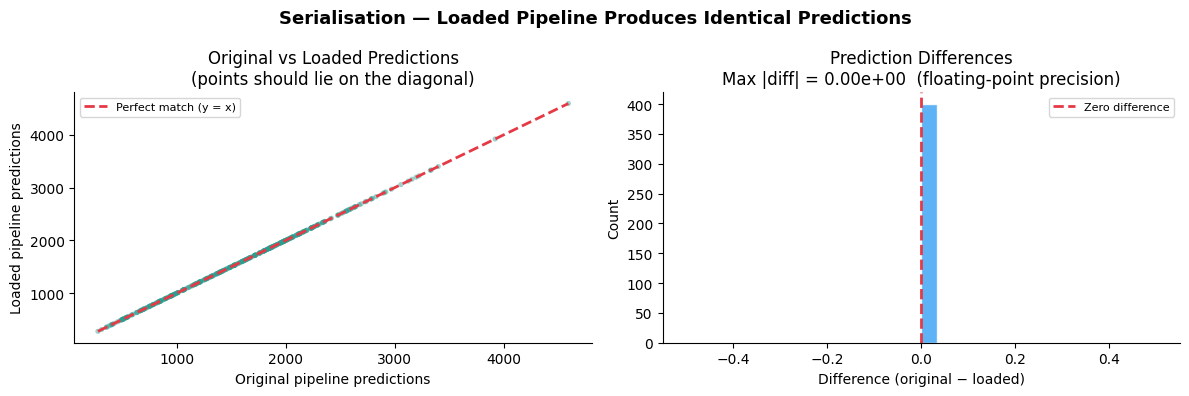

In [13]:
import matplotlib.pyplot as plt
import numpy as np

orig_preds   = best_model.predict(X_test)
diffs        = orig_preds - preds_loaded

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Serialisation — Loaded Pipeline Produces Identical Predictions',
             fontsize=13, fontweight='bold')

# Panel 1 — Scatter: original predictions vs loaded-pipeline predictions
lim = [orig_preds.min(), orig_preds.max()]
axes[0].scatter(orig_preds, preds_loaded, alpha=0.45, s=14,
                color='#2a9d8f', edgecolors='none')
axes[0].plot(lim, lim, color='#e63946', lw=2, ls='--', label='Perfect match (y = x)')
axes[0].set_xlabel('Original pipeline predictions')
axes[0].set_ylabel('Loaded pipeline predictions')
axes[0].set_title('Original vs Loaded Predictions\n(points should lie on the diagonal)')
axes[0].legend(fontsize=8)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Distribution of differences (should be a spike at 0)
axes[1].hist(diffs, bins=30, color='#42A5F5', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='#e63946', lw=2, ls='--', label='Zero difference')
axes[1].set_xlabel('Difference (original − loaded)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Prediction Differences\n'
                  f'Max |diff| = {np.abs(diffs).max():.2e}  '
                  f'(floating-point precision)')
axes[1].legend(fontsize=8)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Notebook → Production: Structural Steps

| Step | Action |
|---|---|
| **Modularisation** | Extract reusable functions and classes into Python modules |
| **Config-Driven** | Move parameters into YAML / JSON files |
| **Entry-Point Scripts** | Create CLI scripts for Training, Inference, Evaluation |

Professional systems do not depend on manual notebook execution — they run as structured applications.

In [14]:
# Example of what a production training script would look like
import logging

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(message)s')
logger = logging.getLogger(__name__)


def train_and_evaluate(X_train, X_test, y_train, y_test, pipeline):
    logger.info(f"Training on {X_train.shape[0]} rows with {X_train.shape[1]} features")
    pipeline.fit(X_train, y_train)
    train_rmse = np.sqrt(mean_squared_error(y_train, pipeline.predict(X_train)))
    test_rmse  = np.sqrt(mean_squared_error(y_test,  pipeline.predict(X_test)))
    logger.info(f"Train RMSE: {train_rmse:.2f} | Test RMSE: {test_rmse:.2f}")
    return pipeline


trained = train_and_evaluate(X_train, X_test, y_train, y_test, full_pipeline)

2026-05-29 23:03:37,396 Training on 1600 rows with 5 features
2026-05-29 23:03:37,420 Train RMSE: 507.11 | Test RMSE: 512.82


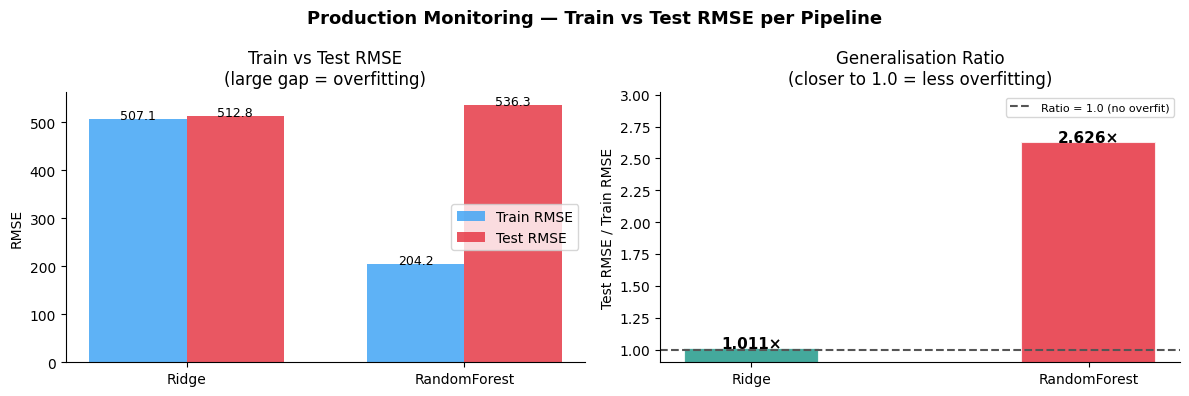

In [15]:
import matplotlib.pyplot as plt
import numpy as np

ridge_train = np.sqrt(mean_squared_error(y_train, full_pipeline.predict(X_train)))
ridge_test  = np.sqrt(mean_squared_error(y_test,  full_pipeline.predict(X_test)))
rf_train    = np.sqrt(mean_squared_error(y_train, rf_pipeline.predict(X_train)))
rf_test     = np.sqrt(mean_squared_error(y_test,  rf_pipeline.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Production Monitoring — Train vs Test RMSE per Pipeline',
             fontsize=13, fontweight='bold')

# Panel 1 — Grouped bar: train vs test per model
x, w = np.arange(2), 0.35
train_vals = [ridge_train, rf_train]
test_vals  = [ridge_test,  rf_test]

b1 = axes[0].bar(x - w/2, train_vals, w, color='#42A5F5', alpha=0.85, label='Train RMSE')
b2 = axes[0].bar(x + w/2, test_vals,  w, color='#e63946', alpha=0.85, label='Test RMSE')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Ridge', 'RandomForest'])
axes[0].set_ylabel('RMSE')
axes[0].set_title('Train vs Test RMSE\n(large gap = overfitting)')
axes[0].legend()
for bar, val in zip(list(b1) + list(b2), train_vals + test_vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.6,
                 f'{val:.1f}', ha='center', fontsize=9)
axes[0].spines[['top', 'right']].set_visible(False)

# Panel 2 — Overfit ratio (test/train): 1.0 = perfect generalisation
ratios = [t / tr for t, tr in zip(test_vals, train_vals)]
cols   = ['#2a9d8f' if r < 1.15 else '#e63946' for r in ratios]
bars   = axes[1].bar(['Ridge', 'RandomForest'], ratios,
                     color=cols, edgecolor='white', linewidth=1.5, alpha=0.88, width=0.4)
axes[1].axhline(1.0, color='#555', lw=1.5, ls='--', label='Ratio = 1.0 (no overfit)')
for bar, val in zip(bars, ratios):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f'{val:.3f}×', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('Test RMSE / Train RMSE')
axes[1].set_title('Generalisation Ratio\n(closer to 1.0 = less overfitting)')
axes[1].legend(fontsize=8)
axes[1].set_ylim(0.9, max(ratios) * 1.15)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

## Key Takeaways

- `Pipeline` chains preprocessing + model into a **single reproducible object**.
- `ColumnTransformer` handles mixed data types with parallel sub-pipelines.
- Unified `GridSearchCV` tunes both preprocessing and model hyperparameters.
- Cross-validation with pipelines **automatically prevents data leakage** per fold.
- Serialise the entire pipeline — not just the model — for deployment.